In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

def fix_lats(delta):
    delta=delta.rename({'longitude': 'lon', 'latitude': 'lat'})
    if 'longitude' in delta.coords:
        delta = delta.rename({'longitude': 'lon'})
    if 'latitude' in delta.coords:
        delta = delta.rename({'latitude': 'lat'})
    return delta

period='rcp45'
variable='pr'
domain = 'd03'
if variable == "t":
    var = 'T2'
    filename = 't_'+domain+'_daily_newdim'
elif variable == "pr":
    var = 'pr'
    filename = 'pr_'+domain+'_daily'
elif variable == "wind":
    var = 'wspd'
    if domain=="d03":
        filename =  'wind_d03_daily_wspd'#'wspd_'+domain+'_mon'
    else:
        filename = "wind_"+domain+'_daily'
    
geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'  #'/Users/evagnegy/Desktop/CanESM2_WRF_Eval/domain/geo_em.'+domain+'.nc'
basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
#gridded_data_path = '/Users/evagnegy/Desktop/CanESM2_WRF_Eval/gridded_model_data/daily/'
gridded_data_path = basepath+'historical/variables_complete/'
future_data_path = basepath+period+'/variables_complete/'

# === Paths and filenames ===
hist_path = gridded_data_path + filename + '.nc'
fut_path = future_data_path + filename + '.nc'

#fut_path = future_data_path + filename + f'_{period}.nc'
out_path = f"{filename}_{period}_monthly_deltas.nc"

# === Load land mask ===
landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()
landmask = landmask.rename({'south_north': 'lat', 'west_east': 'lon'})  # ensure standard naming
if 'south_north' in landmask.coords:
    landmask = landmask.rename({'south_north': 'lat'})
if 'west_east' in landmask.coords:
    landmask = landmask.rename({'west_east': 'lon'})
print(landmask.dims)
# landmask= landmask.rename({'lon':'longitude' , 'lat:'latitude'})
print(np.shape(landmask))
# === Load data ===
var_hist = xr.open_dataset(hist_path)[var]
var_fut = xr.open_dataset(fut_path)[var]
# === Ensure lat/lon are consistent ===
#var_hist = var_hist.rename({'south_north': 'lat', 'west_east': 'lon'})
#var_fut = var_fut.rename({'south_north': 'lat', 'west_east': 'lon'})

# === Group by month and take mean ===
hist_monthly = var_hist.groupby('time.month').mean('time')
fut_monthly = var_fut.groupby('time.month').mean('time')

# === Compute fractional change (future - historical) / historical ===
delta = (fut_monthly - hist_monthly)  # shape: (month, lat, lon)

if variable=='t':
    delta = (delta ) 
    delta=fix_lats(delta)
    hist_monthly=fix_lats(hist_monthly)
    fut_monthly=fix_lats(fut_monthly)
else:
    delta = (delta / (hist_monthly)) * 100

('lat', 'lon')
(300, 300)


/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unab

In [2]:
var_hist

<xarray.DataArray 'pr' (time: 7305, lon: 300, lat: 300)> Size: 5GB
[657450000 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 58kB 1986-01-01T11:30:00 ... 2005-12-31T11...
    lon      (lon, lat) float64 720kB ...
    lat      (lon, lat) float64 720kB ...

In [3]:
import numpy as np
import xarray as xr

def get_seasonal(da):
#da=var_hist
    # ── 1. drop Feb 29 to keep a clean 365-day calendar ─────────────────────────
    da = da.sel(time=~((da.time.dt.month == 2) & (da.time.dt.day == 29)))
    
    # ── 2. compute the mean seasonal cycle ──────────────────────────────────────
    #    Group by calendar day (day-of-year) and average over all years.
    #    This is exactly the "period-averaged daily Tas for each calendar day"
    #    described by Chen et al. (2019).
    #
    #    NOTE: after dropping Feb-29, day-of-year values jump from 59 to 61
    #    in leap years. Using (month, day) as the grouping key avoids that
    #    ambiguity and always produces exactly 365 groups.
    
    seasonal_cycle = da.groupby("time.dayofyear").mean(dim="time")
    # Result shape: (dayofyear: 365, longitude: 300, latitude: 300)
    
    # ── 3. compute daily anomalies ───────────────────────────────────────────────
    #    Subtract the seasonal cycle from the original data.
    #    xarray's groupby subtraction handles the broadcasting automatically.
    
    anomalies = da.groupby("time.dayofyear") - seasonal_cycle
    # Result shape: (time: 7305, longitude: 300, latitude: 300)
    
    # ── 4. quick checks ──────────────────────────────────────────────────────────
    print("Seasonal cycle shape :", seasonal_cycle.shape)   # (365, 300, 300)
    print("Anomalies shape      :", anomalies.shape)        # (7305, 300, 300)
    print("Mean of anomalies (should be ~0):", float(anomalies.mean()))
    
    # ── 5. optional: compute seasonal amplitude at each grid point ───────────────
    #    Amplitude = max(seasonal_cycle) - min(seasonal_cycle)
    #    This is the definition used by Chen et al. (2019).
    
    amplitude = seasonal_cycle.max(dim="dayofyear") - seasonal_cycle.min(dim="dayofyear")
    print("Amplitude shape:", amplitude.shape)              # (300, 300)
    
    # ── 6. optional: compute the day of maximum and minimum Tas ─────────────────
    #    Also used by Chen et al. (2019) to characterise the seasonal phase.
    
    day_of_max = seasonal_cycle.argmax(dim="dayofyear") + 1   # +1 → 1-indexed
    day_of_min = seasonal_cycle.argmin(dim="dayofyear") + 1
    
    # ── 7. optional: compute SD of daily anomalies (= Tas variability) ───────────
    #    Chen et al. (2019) use the SD of daily anomalies to quantify variability.
    
    tas_variability = anomalies.std(dim="time")
    print("Variability (SD) shape:", tas_variability.shape)  # (300, 300)
    
    # ── 8. optional: save results ────────────────────────────────────────────────
    ds_out = xr.Dataset({
        "amplitude"      : amplitude,
        "day_of_max"     : day_of_max,
        "day_of_min"     : day_of_min,
    })
    return ds_out

#ds_out.to_netcdf("seasonal_cycle_output.nc")
#print("Saved to seasonal_cycle_output.nc")

In [4]:
hist_da=get_seasonal(var_hist)
rcp85_da=get_seasonal(var_fut)

Seasonal cycle shape : (366, 300, 300)
Anomalies shape      : (7300, 300, 300)
Mean of anomalies (should be ~0): 4.026140625017328e-16
Amplitude shape: (300, 300)
Variability (SD) shape: (300, 300)
Seasonal cycle shape : (366, 300, 300)
Anomalies shape      : (7300, 300, 300)
Mean of anomalies (should be ~0): 5.366793956644436e-16
Amplitude shape: (300, 300)
Variability (SD) shape: (300, 300)


ERROR 1: PROJ: proj_create_from_database: Open of /home/amh001/space_fs7/software_2022/python/py_2024/share/proj failed


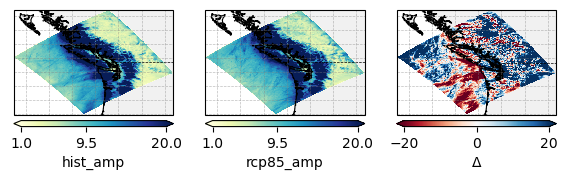

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Get lons and lats
lons = var_hist['lon'].values
lats = var_hist['lat'].values


# --- Plot ---
fig, axes = plt.subplots(
    1, 3, figsize=(7, 4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.flatten()
ax = axes[0]

vmin=1;vmax=20    
cf = ax.pcolormesh(
    lons, lats, hist_da['amplitude'],
    cmap='YlGnBu',
    vmin=vmin, vmax=vmax,
    transform=ccrs.PlateCarree()
)
    
# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', 
                  alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = False

#ax.set_title(season, fontsize=13, fontweight='medium')
bbox = ax.get_position()
        # Create a new axis below it for the colorbar
cbar_ax = fig.add_axes([
    bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
    bbox.width, 0.015         # same width, small height
])
cbar = fig.colorbar(cf, cax=cbar_ax, extend='both', orientation="horizontal")
cbar.set_label('hist_amp', fontsize=10)
cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
####################
ax = axes[1]

vmin=1;vmax=20    
cf = ax.pcolormesh(
    lons, lats, rcp85_da['amplitude'],
    cmap='YlGnBu',
    vmin=vmin, vmax=vmax,
    transform=ccrs.PlateCarree()
)
    
# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', 
                  alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = False

#ax.set_title(season, fontsize=13, fontweight='medium')
bbox = ax.get_position()
        # Create a new axis below it for the colorbar
cbar_ax = fig.add_axes([
    bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
    bbox.width, 0.015         # same width, small height
])
cbar = fig.colorbar(cf, cax=cbar_ax, extend='both', orientation="horizontal")
cbar.set_label('rcp85_amp', fontsize=10)
cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
#plt.colorbar(cf)
##################

ax = axes[2]

vmin=-20;vmax=20    
cf = ax.pcolormesh(
    lons, lats, 100.0*(rcp85_da['amplitude']-hist_da['amplitude'])/hist_da['amplitude'],
    cmap='RdBu',
    vmin=vmin, vmax=vmax,
    transform=ccrs.PlateCarree()
)
    
# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', 
                  alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = False

#ax.set_title(season, fontsize=13, fontweight='medium')
bbox = ax.get_position()
        # Create a new axis below it for the colorbar
cbar_ax = fig.add_axes([
    bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
    bbox.width, 0.015         # same width, small height
])
cbar = fig.colorbar(cf, cax=cbar_ax, extend='both', orientation="horizontal")
cbar.set_label(r'$\Delta$', fontsize=10)
cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])



In [6]:
import numpy as np
import xarray as xr
import gc

# ── 1. Force garbage collection first ────────────────────────────────────────
gc.collect()

# ── 2. Work directly with numpy to avoid xarray overhead ─────────────────────
# Extract numpy arrays (float32 to halve memory)
hist_amp  = hist_da['amplitude'].values.astype(np.float32)
rcp85_amp = rcp85_da['amplitude'].values.astype(np.float32)
lat_2d    = hist_da['lat'].values.astype(np.float32)
land_mask_np  = (landmask == 1).values  # boolean numpy array
ocean_mask_np = (landmask == 0).values  # boolean numpy array

# ── 3. Free xarray objects from memory immediately ───────────────────────────
del hist_da, rcp85_da
gc.collect()

# ── 4. Compute percentage change in numpy (no extra copies) ──────────────────
# Use np.errstate to avoid warnings from division
with np.errstate(invalid='ignore', divide='ignore'):
    pct_change = np.where(
        hist_amp != 0,
        100.0 * (rcp85_amp - hist_amp) / hist_amp,
        np.nan
    ).astype(np.float32)

# free amplitude arrays immediately
del hist_amp, rcp85_amp
gc.collect()

# ── 5. Compute weights ────────────────────────────────────────────────────────
weights = np.cos(np.deg2rad(lat_2d)).astype(np.float32)
del lat_2d
gc.collect()

# ── 6. Weighted mean function ─────────────────────────────────────────────────
def weighted_masked_mean(data, weights, mask):
    """
    Compute weighted mean of data where mask is True.
    All arrays are 2D numpy arrays.
    """
    masked_data    = np.where(mask, data,    np.nan)
    masked_weights = np.where(mask, weights, np.nan)

    # weighted mean = sum(w * x) / sum(w)
    numerator   = np.nansum(masked_data * masked_weights)
    denominator = np.nansum(masked_weights)

    return numerator / denominator

# ── 7. Compute land and ocean averages ───────────────────────────────────────
land_avg  = weighted_masked_mean(pct_change, weights, land_mask_np)
ocean_avg = weighted_masked_mean(pct_change, weights, ocean_mask_np)

print(f"Land  weighted mean pct change: {land_avg:.4f} %")
print(f"Ocean weighted mean pct change: {ocean_avg:.4f} %")

# ── 8. Clean up ───────────────────────────────────────────────────────────────
del pct_change, weights, land_mask_np, ocean_mask_np
gc.collect()

Land  weighted mean pct change: 11.4087 %
Ocean weighted mean pct change: 2.0394 %


0

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── Configuration ─────────────────────────────────────────────────────────────
OUTPUT_DIR = '/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/'
PLOT_DIR   = '../Figures/'
os.makedirs(PLOT_DIR, exist_ok=True)

variables = ['t', 'pr', 'wind']
periods   = ['rcp45', 'rcp85']

# Units label for each variable
UNITS = {
    't'    : 'K',
    'pr'   : 'mm/day',
    'wind' : 'm/s',
}

# ── Load all CSVs ─────────────────────────────────────────────────────────────
all_data = {}
for var_name in variables:
    for period in periods:
        csv_path = f"{OUTPUT_DIR}{var_name}_seasonalAmp_landocean_avg_{period}.csv"
        if not os.path.exists(csv_path):
            print(f"  Skipping (not found): {csv_path}")
            continue
        df = pd.read_csv(csv_path, index_col="Region")
        all_data[(var_name, period)] = df
        print(f"  Loaded: {csv_path}")

# ── Plot ──────────────────────────────────────────────────────────────────────
# One figure per variable, one subplot per metric
METRICS = [
    "Relative Amplitude Change (%)",
    "Delta Day of Maximum (days)",
    "Delta Day of Minimum (days)",
]

COLORS = {
    'rcp45' : {'Land': '#a8d5a2', 'Ocean': '#a2c4d5'},   # muted green / blue
    'rcp85' : {'Land': '#2e8b57', 'Ocean': '#1f5f8b'},   # darker green / blue
}

for var_name in variables:
    # Check at least one period loaded
    loaded_periods = [p for p in periods if (var_name, p) in all_data]
    if not loaded_periods:
        print(f"  No data found for {var_name}, skipping.")
        continue

    fig, axes = plt.subplots(1, len(METRICS), figsize=(14, 5), sharey=False)
    fig.suptitle(
        f"Seasonal Amplitude Change — {var_name.upper()}",
        fontsize=14, fontweight='bold', y=1.02
    )

    for ax, metric in zip(axes, METRICS):
        # Build a small dataframe: rows = Land/Ocean, cols = periods
        plot_data = {}
        for period in loaded_periods:
            if (var_name, period) in all_data:
                plot_data[period] = all_data[(var_name, period)][metric]

        df_plot = pd.DataFrame(plot_data)   # index = Land, Ocean

        # Bar positions
        n_periods = len(df_plot.columns)
        n_regions = len(df_plot.index)      # 2 (Land, Ocean)
        bar_width = 0.35
        x = range(n_regions)

        for i, period in enumerate(df_plot.columns):
            offsets = [xi + i * bar_width for xi in x]
            bars = ax.bar(
                offsets,
                df_plot[period],
                width     = bar_width,
                label     = period,
                color     = [COLORS[period][r] for r in df_plot.index],
                edgecolor = 'black',
                linewidth = 0.7,
            )
            # Value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + (0.02 * abs(height) if height >= 0 else -0.05 * abs(height)),
                    f"{height:+.2f}",
                    ha='center', va='bottom', fontsize=8,
                )

        # Reference line at zero
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

        # X-axis ticks centred between grouped bars
        tick_pos = [xi + bar_width * (n_periods - 1) / 2 for xi in x]
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(df_plot.index, fontsize=11)

        ax.set_title(metric, fontsize=10, pad=6)
        ax.set_ylabel(metric, fontsize=9)
        ax.legend(title="Scenario", fontsize=8, title_fontsize=8)
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plot_path = f"{PLOT_DIR}{var_name}_seasonalAmp_landocean_barplot.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved: {plot_path}")

print("\nAll plots done.")

  Loaded: /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/t_seasonalAmp_landocean_avg_rcp45.csv
  Loaded: /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/t_seasonalAmp_landocean_avg_rcp85.csv
  Loaded: /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/pr_seasonalAmp_landocean_avg_rcp45.csv
  Loaded: /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/pr_seasonalAmp_landocean_avg_rcp85.csv
  Loaded: /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/wind_seasonalAmp_landocean_avg_rcp45.csv
  Loaded: /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/wind_seasonalAmp_landocean_avg_rcp85.csv
  Saved: ../Figures/t_seasonalAmp_landocean_barplot.png
  Saved: ../Figures/pr_seasonalAmp_landocean_barplot.png
  Saved: ../Figures/wind_seasonalAmp_landocean_barplot.png

All plots done.


this  code was run for all vars and sceanrios using 

#### land_mask = (landmask == 1)
ocean_mask = (landmask == 0)
import numpy as np
import xarray as xr

# ── 1. Reduce precision ──────────────────────────────────────────────────────
hist_amp  = hist_da['amplitude'].astype(np.float32)
rcp85_amp = rcp85_da['amplitude'].astype(np.float32)

# ── 2. Compute percentage change ─────────────────────────────────────────────
pct_change = (100.0 * (rcp85_amp - hist_amp) / hist_amp).astype(np.float32)

# ── 3. Check the shape of lat to understand the grid ─────────────────────────
print("lat shape:", hist_da['lat'].values.shape)
print("pct_change dims:", pct_change.dims)

# ── 4. Build 2D weights matching your curvilinear grid ───────────────────────
# Since lat is 2D (longitude, latitude), weights must also be 2D
lat_2d = hist_da['lat'].values.astype(np.float32)   # shape (300, 300)
lat_weights_2d = np.cos(np.deg2rad(lat_2d))          # shape (300, 300)

# Wrap as a DataArray with the same dims as pct_change
lat_weights_da = xr.DataArray(
    lat_weights_2d,
    dims=pct_change.dims    # e.g. ('longitude', 'latitude')
)

# ── 5. Weighted masked means ──────────────────────────────────────────────────
# Use the spatial dims of pct_change (not hardcoded 'lon','lat')
spatial_dims = pct_change.dims   # ('longitude', 'latitude')

land_avg = (
    pct_change
    .where(land_mask)
    .weighted(lat_weights_da)
    .mean(dim=list(spatial_dims), skipna=True)
)

ocean_avg = (
    pct_change
    .where(ocean_mask)
    .weighted(lat_weights_da)
    .mean(dim=list(spatial_dims), skipna=True)
)

print("Land  avg pct change:", float(land_avg))
print("Ocean avg pct change:", float(ocean_avg))

# ── 6. Clean up ───────────────────────────────────────────────────────────────
del hist_amp, rcp85_amp, pct_change, lat_weights_2d, lat_weights_da
import gc
gc.collect()

If we follow the same method as chen 2019 and use daily values to extract the seasonal cylce, we do find an increase in amplitude across most of the domain. 

In [13]:


# === Area weights ===
weights = np.cos(np.deg2rad(var_hist['lat'].values))
#weights=weights.rename({'longitude': 'lon', 'latitude': 'lat'})
#if 'longitude' in delta.coords:
#    weights = weights.rename({'longitude': 'lon'})
#if 'latitude' in delta.coords:
#    weights = weights.rename({'latitude': 'lat'})
#print(weights)
#weights = weights
#weights = weights.broadcast_like(delta)
# Apply mask to weights with multiplication (avoids NaNs)
#print(weights.dims)
land_weights = weights * land_mask
ocean_weights = weights* ocean_mask
print('here...starting loop')
# Safe weighted averages
# land_mean = hist_mo_l.weighted(land_weights).mean(dim=['lat', 'lon'])
#ocean_mean = hist_mo_oc.weighted(ocean_weights).mean(dim=['lat', 'lon'])
#land_fut = fut_mo_l.weighted(land_weights).mean(dim=['lat', 'lon'])
#ocean_fut = fut_mo_oc.weighted(ocean_weights).mean(dim=['lat', 'lon'])
land_del =np.zeros(12)
ocean_del=np.zeros(12)
land_hist =np.zeros(12)
ocean_hist=np.zeros(12)
land_fut =np.zeros(12)
ocean_fut=np.zeros(12)
#print(land_mask.dims, delta.dims)
#print(land_mask, delta)

for kk in np.arange(12):
    X=hist_monthly[kk,:,:]
    del_mo_l = X.where(land_mask)
    del_mo_oc = X.where(ocean_mask)
    land_hist[kk] = del_mo_l.mean(dim=['lon', 'lat'])
    ocean_hist[kk] = del_mo_oc.mean(dim=['lon', 'lat'])   
for kk in np.arange(12):
    X=fut_monthly[kk,:,:]
    del_mo_l = X.where(land_mask)
    del_mo_oc = X.where(ocean_mask)
    land_fut[kk] = del_mo_l.mean(dim=['lon', 'lat'])
    ocean_fut[kk] = del_mo_oc.mean(dim=['lon', 'lat']) 

here...starting loop


In [5]:


# ─────────────────────────────────────────────
# 2.  Define seasons  (0-based month indices)
# ─────────────────────────────────────────────
seasons = {
    'DJF': [11, 0, 1],   # Dec, Jan, Feb
    'MAM': [2,  3, 4],   # Mar, Apr, May
    'JJA': [5,  6, 7],   # Jun, Jul, Aug
    'SON': [8,  9, 10],  # Sep, Oct, Nov
}

# ─────────────────────────────────────────────
# 3.  Seasonal averages over land & ocean
# ─────────────────────────────────────────────
season_land  = {}
season_ocean = {}

for season, months in seasons.items():
    season_land[season]  = np.mean([land_del[m]  for m in months])
    season_ocean[season] = np.mean([ocean_del[m] for m in months])

# ─────────────────────────────────────────────
# 4.  Print results
# ─────────────────────────────────────────────
print("\n{'Season':<6} {'Land':>10} {'Ocean':>10}")
print("-" * 28)
for season in seasons:
    print(f"{season:<6} {season_land[season]:>10.4f} {season_ocean[season]:>10.4f}")

# ─────────────────────────────────────────────
# 5.  Optional – compute directly from delta
#     (spatially correct, area-weighted)
# ─────────────────────────────────────────────
print("\n── Area-weighted seasonal averages ──")

for season, months in seasons.items():
    land_vals  = []
    ocean_vals = []

    for m in months:
        X = delta[m, :, :]
        land_vals.append(X.where(land_mask))
        ocean_vals.append(X.where(ocean_mask))

    # Stack along a new 'month' dimension and average
    land_stack  = xr.concat(land_vals,  dim='month')
    ocean_stack = xr.concat(ocean_vals, dim='month')

    sea_land_mean  = land_stack.mean(dim=['month', 'lon', 'lat'])
    sea_ocean_mean = ocean_stack.mean(dim=['month', 'lon', 'lat'])

    print(f"{season}  land: {sea_land_mean.values:.4f}  "
          f"ocean: {sea_ocean_mean.values:.4f}")


{'Season':<6} {'Land':>10} {'Ocean':>10}
----------------------------
DJF        3.0897     2.7318
MAM        2.7063     2.6476
JJA        3.3668     2.3318
SON        3.2356     2.8798

── Area-weighted seasonal averages ──
DJF  land: 3.0897  ocean: 2.7318
MAM  land: 2.7063  ocean: 2.6476
JJA  land: 3.3668  ocean: 2.3318
SON  land: 3.2356  ocean: 2.8798


In [15]:
# 1. Define your "month" data for the two periods
# These could be 12-element arrays (means per month)
# Example:
# hist_land  = np.array([...12 vals...])
# fut_land   = np.array([...12 vals...])
# hist_ocean = np.array([...12 vals...])
# fut_ocean  = np.array([...12 vals...])

# 2. Create seasonal dictionaries for each
def seasonal_dict(monthly_array, seasons):
    return {s: np.mean([monthly_array[m] for m in months]) for s, months in seasons.items()}

season_names = list(seasons.keys())
# Dictionaries for each period+surface type
hist_land_dict  = seasonal_dict(land_hist,  seasons)
fut_land_dict   = seasonal_dict(land_fut,   seasons)
hist_ocean_dict = seasonal_dict(ocean_hist, seasons)
fut_ocean_dict  = seasonal_dict(ocean_fut,  seasons)

# Optionally, deltas
delta_land_dict  = {s: fut_land_dict[s]  - hist_land_dict[s]  for s in season_names}
delta_ocean_dict = {s: fut_ocean_dict[s] - hist_ocean_dict[s] for s in season_names}

In [16]:
# For historical
amplitude_hist_land  = hist_land_dict['JJA']  - hist_land_dict['DJF']
amplitude_hist_ocean = hist_ocean_dict['JJA'] - hist_ocean_dict['DJF']

# For future
amplitude_fut_land   = fut_land_dict['JJA']   - fut_land_dict['DJF']
amplitude_fut_ocean  = fut_ocean_dict['JJA']  - fut_ocean_dict['DJF']

# Change in amplitude
amplitude_change_land  = amplitude_fut_land  - amplitude_hist_land
amplitude_change_ocean = amplitude_fut_ocean - amplitude_hist_ocean

# If you only have deltas, it's just:
amplitude_change_land2  = delta_land_dict['JJA']  - delta_land_dict['DJF']
amplitude_change_ocean2 = delta_ocean_dict['JJA'] - delta_ocean_dict['DJF']
# (these two will be equivalent to the above)

In [17]:
print(f"\n{'Period':<10}{'Land':>12}{'Ocean':>12}")
print('-'*34)
print(f"Hist ampl. {amplitude_hist_land:12.2f}{amplitude_hist_ocean:12.2f}")
print(f"Fut  ampl. {amplitude_fut_land:12.2f}{amplitude_fut_ocean:12.2f}")
print(f"Change    {amplitude_change_land:12.2f}{amplitude_change_ocean:12.2f}")


Period            Land       Ocean
----------------------------------
Hist ampl.        18.35        6.16
Fut  ampl.        18.63        5.76
Change            0.28       -0.40


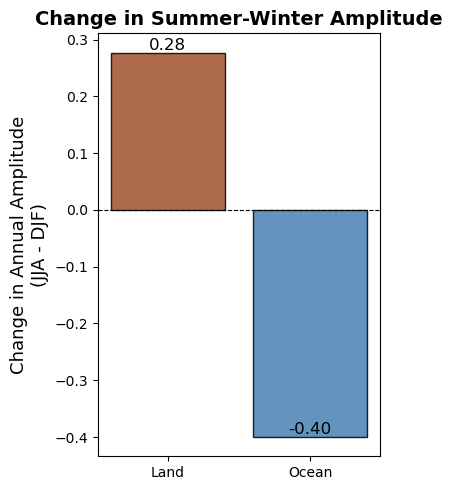

In [18]:
labels = ['Land', 'Ocean']
amplitudes = [amplitude_change_land, amplitude_change_ocean]

plt.figure(figsize=(4,5))
bars = plt.bar(labels, amplitudes, color=['sienna', 'steelblue'], alpha=0.85, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.ylabel('Change in Annual Amplitude\n(JJA - DJF)', fontsize=13)
plt.title('Change in Summer-Winter Amplitude', fontsize=14, fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

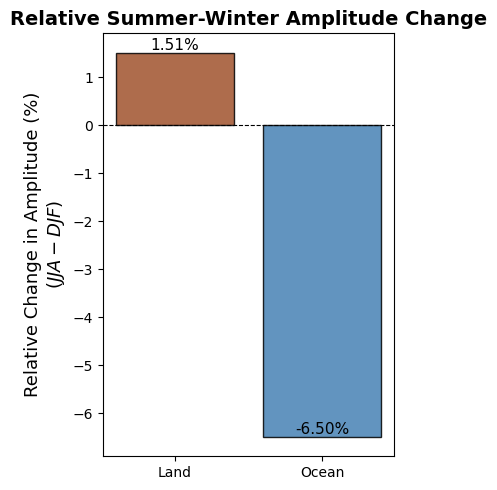

Relative amplitude change (%)
 Land:  1.51%
 Ocean: -6.50%


In [19]:
# --- Assuming you already have these:
# amplitude_hist_land, amplitude_hist_ocean        (historical amplitudes)
# amplitude_fut_land, amplitude_fut_ocean          (future amplitudes)

# --- Compute relative change
rel_change_land  = 100 * (amplitude_fut_land  - amplitude_hist_land)  / amplitude_hist_land
rel_change_ocean = 100 * (amplitude_fut_ocean - amplitude_hist_ocean) / amplitude_hist_ocean

rel_change_vals = [rel_change_land, rel_change_ocean]
labels = ['Land', 'Ocean']

# --- Bar Plot ---
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 5))
bars = plt.bar(labels, rel_change_vals, color=['sienna', 'steelblue'], edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.ylabel('Relative Change in Amplitude (%)\n$(JJA-DJF)$', fontsize=13)
plt.title('Relative Summer-Winter Amplitude Change', fontsize=14, fontweight='bold')

# Annotate values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# --- Print summary table as well
print("Relative amplitude change (%)")
print(f" Land:  {rel_change_land:.2f}%")
print(f" Ocean: {rel_change_ocean:.2f}%")

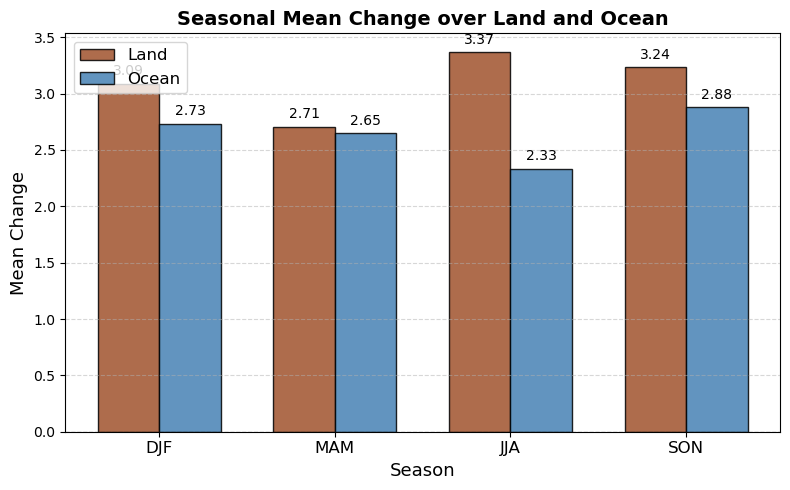

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────
# Data
# ─────────────────────────────────────────────
season_names = list(seasons.keys())           # ['DJF', 'MAM', 'JJA', 'SON']
land_vals    = [season_land[s]  for s in season_names]
ocean_vals   = [season_ocean[s] for s in season_names]

# ─────────────────────────────────────────────
# Bar plot setup
# ─────────────────────────────────────────────
x     = np.arange(len(season_names))          # [0, 1, 2, 3]
width = 0.35                                  # width of each bar

fig, ax = plt.subplots(figsize=(8, 5))

bars_land  = ax.bar(x - width/2, land_vals,  width,
                    label='Land',  color='sienna',    alpha=0.85, edgecolor='black')
bars_ocean = ax.bar(x + width/2, ocean_vals, width,
                    label='Ocean', color='steelblue', alpha=0.85, edgecolor='black')

# ─────────────────────────────────────────────
# Labels & formatting
# ─────────────────────────────────────────────
ax.set_xlabel('Season', fontsize=13)
ax.set_ylabel('Mean Change', fontsize=13)
ax.set_title('Seasonal Mean Change over Land and Ocean', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(season_names, fontsize=12)
ax.legend(fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')  # zero line
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ─────────────────────────────────────────────
# Add value labels on top of each bar
# ─────────────────────────────────────────────
def label_bars(bars):
    for bar in bars:
        height = bar.get_height()
        offset = 0.01 if height >= 0 else -0.03   # above/below bar
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=10)

label_bars(bars_land)
label_bars(bars_ocean)

plt.tight_layout()
plt.savefig('seasonal_land_ocean.png', dpi=150, bbox_inches='tight')
plt.show()